# Batch vs Mini-batch Gradient Descent

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Epoch 0, Loss: 0.7531602914904633
Epoch 10, Loss: 0.6590415869649547
Epoch 20, Loss: 0.6187191217742252
Epoch 30, Loss: 0.5829263986183969
Epoch 40, Loss: 0.550592105632603
Epoch 50, Loss: 0.5215880903292259
Epoch 60, Loss: 0.49589286758008355
Epoch 70, Loss: 0.47335684427586366
Epoch 80, Loss: 0.45371515962833764
Epoch 90, Loss: 0.43665102415120094
Batch 0, Loss: 0.7113909837532854
Batch 480, Loss: 0.6712678995301932
Batch 0, Loss: 0.6782106490507821
Batch 480, Loss: 0.6598464053665591
Batch 0, Loss: 0.6622024399883064
Batch 480, Loss: 0.6560700149989824
Batch 0, Loss: 0.6537133760233257
Batch 480, Loss: 0.654279014152045
Batch 0, Loss: 0.6479203603165424
Batch 480, Loss: 0.6524306057877977
Batch 0, Loss: 0.6429237392531811
Batch 480, Loss: 0.6500426005224798
Batch 0, Loss: 0.6380882777805283
Batch 480, Loss: 0.6471475553873594
Batch 0, Loss: 0.6332455819273779
Batch 480, Loss: 0.6438938171317338
Batch 0, Loss: 0.6283783614900244
Batch 480, Loss: 0.6404203804472597
Batch 0, Loss: 0.62

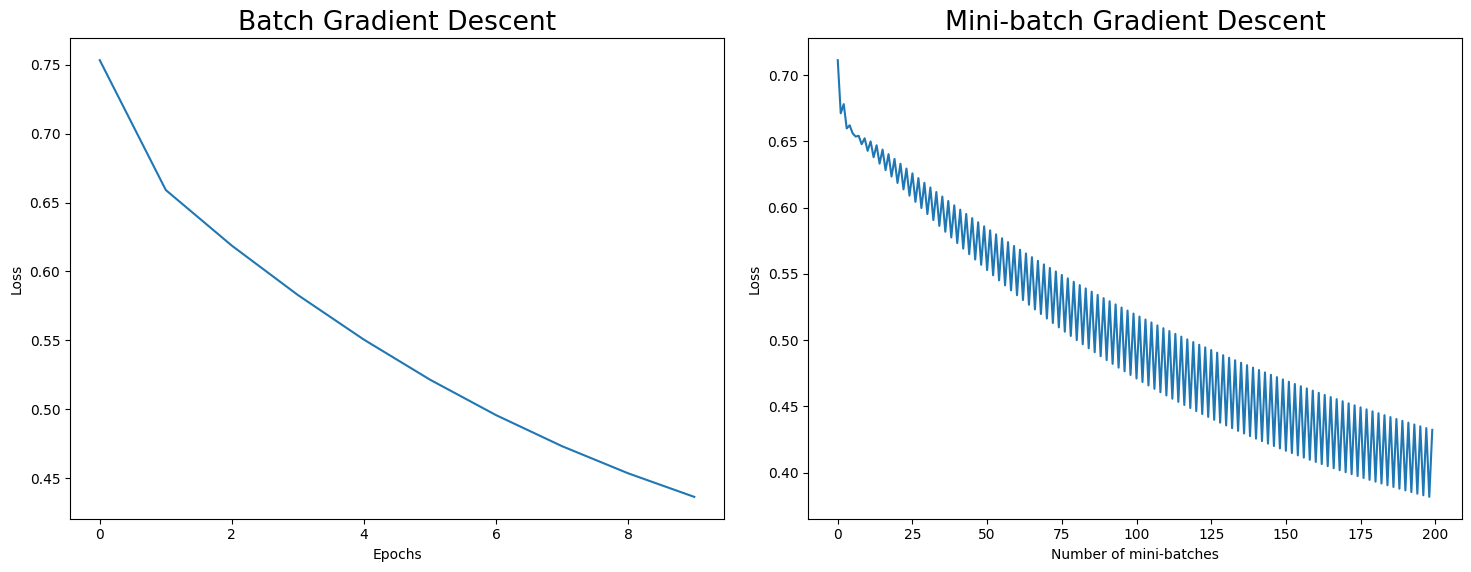

Batch Gradient Descent - Test Accuracy: 0.825
Mini-batch Gradient Descent - Test Accuracy: 0.84


In [ ]:
# @title


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

class MLP:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size) / np.sqrt(input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) / np.sqrt(hidden_size)
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output):
        m = X.shape[0]
        delta2 = (output - y) * sigmoid_derivative(output)
        dW2 = np.dot(self.a1.T, delta2)
        db2 = np.sum(delta2, axis=0, keepdims=True)
        delta1 = np.dot(delta2, self.W2.T) * sigmoid_derivative(self.a1)
        dW1 = np.dot(X.T, delta1)
        db1 = np.sum(delta1, axis=0)
        return dW1, db1, dW2, db2

    def update_params(self, dW1, db1, dW2, db2, learning_rate):
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2

def loss_function(y, output):
    return np.mean(-y * np.log(output) - (1 - y) * np.log(1 - output))

def train(model, X, y, epochs, learning_rate, batch_size=None):
    # Number of exmaples
    m = X.shape[0]

    losses = []
    for epoch in range(epochs):
        if batch_size is None: # Batch Gradient Descent
            # Forward pass on the entire dataset
            output = model.forward(X)

            # Update paramters based on error on the entire dataset
            dW1, db1, dW2, db2 = model.backward(X, y, output)
            model.update_params(dW1, db1, dW2, db2, learning_rate)

            if epoch % 10 == 0:
              # Compute loss for the entire dataset
              loss = loss_function(y, output)
              losses.append(loss)
              print(f"Epoch {epoch}, Loss: {loss}")

        else: # Mini-batch Gradient Descent
            for i in range(0, m, batch_size):
                # Forward pass on batch
                X_batch = X[i:i+batch_size]
                y_batch = y[i:i+batch_size]
                output = model.forward(X_batch)

                # Update paramters based on current batch
                dW1, db1, dW2, db2 = model.backward(X_batch, y_batch, output)
                model.update_params(dW1, db1, dW2, db2, learning_rate)

                if i % 30 == 0:
                  # Compute batch loss
                  loss = loss_function(y_batch, output)
                  losses.append(loss)
                  print(f"Batch {i}, Loss: {loss}")

    return losses

# Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape y to have shape (n_samples, 1)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# Initialize and train models
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = 0.001
epochs = 100

model_batch = MLP(input_size, hidden_size, output_size)
model_mini_batch = MLP(input_size, hidden_size, output_size)

losses_batch = train(model_batch, X_train_scaled, y_train, epochs, learning_rate)
losses_mini_batch = train(model_mini_batch, X_train_scaled, y_train, epochs, learning_rate, batch_size=32)

# Plot learning curves in two subfigures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Increase title size
plt.rcParams['font.size'] = 16

# Increase ticks sizes
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

ax1.plot(losses_batch)
ax1.set_title('Batch Gradient Descent')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')

ax2.plot(losses_mini_batch)
ax2.set_title('Mini-batch Gradient Descent')
ax2.set_xlabel('Number of mini-batches')
ax2.set_ylabel('Loss')

plt.tight_layout()
plt.show()

# Evaluate models
def evaluate(model, X, y):
    predictions = model.forward(X)
    accuracy = np.mean((predictions > 0.5) == y)
    return accuracy

print("Batch Gradient Descent - Test Accuracy:", evaluate(model_batch, X_test_scaled, y_test))
print("Mini-batch Gradient Descent - Test Accuracy:", evaluate(model_mini_batch, X_test_scaled, y_test))

# Exponential Moving Average (EMA)

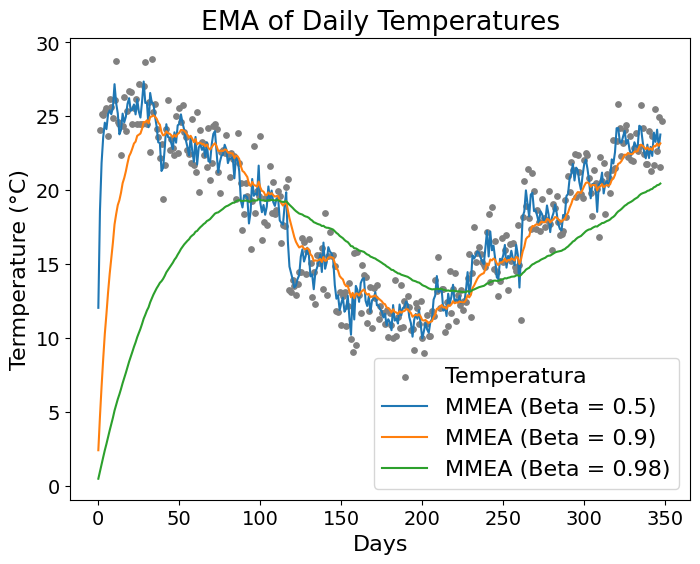

In [ ]:
# Define monthly mean temperatures (in Celsius) for Southern Hemisphere - Example values
monthly_means_southern = [25.0, 24.0, 22.5, 18.8, 15.1, 12.0, 11.3, 13.0, 15.5, 18.5, 21.0, 23.5]

# Define monthly standard deviations (in Celsius) for Southern Hemisphere - Example values
monthly_std_devs_southern = [1.5, 1.7, 1.8, 1.7, 1.5, 1.4, 1.3, 1.4, 1.5, 1.6, 1.7, 1.6]

# Generate synthetic daily temperature data for a year
daily_temperatures_southern = []
for month in range(12):
    num_days = np.random.randint(28, 31)  # Random number of days per month (approximate)
    monthly_temperatures = np.random.normal(monthly_means_southern[month], monthly_std_devs_southern[month], num_days)
    daily_temperatures_southern.extend(monthly_temperatures)

# Define different values of beta
beta_values = [0.5, 0.9, 0.98]

def ema(data_points, beta=0.9):
  emas = []
  vt = 0  # Initialize the moving average
  for t in range(0, len(data_points)):
      vt = beta * vt +  (1 - beta) * data_points[t]
      emas.append(vt)
  return emas

# Calculate EMA curves for each beta value
ema_curves = {}
for beta in beta_values:
    ema_curves[beta] = ema(daily_temperatures_southern, beta)

# Create a scatterplot
plt.figure(figsize=(8, 6))

# Plot temperature data as a scatter plot
days = range(1, len(daily_temperatures_southern) + 1)
plt.scatter(days, daily_temperatures_southern, label='Temperatura', color='grey', s=15, marker='o')

# Plot EWMA curves for each beta value
for beta, curve in ema_curves.items():
    plt.plot(curve, label=f'MMEA (Beta = {beta})')

plt.title('EMA of Daily Temperatures')
plt.xlabel('Days')
plt.ylabel('Termperature (°C)')
plt.legend()
plt.show()

# Bias Correction

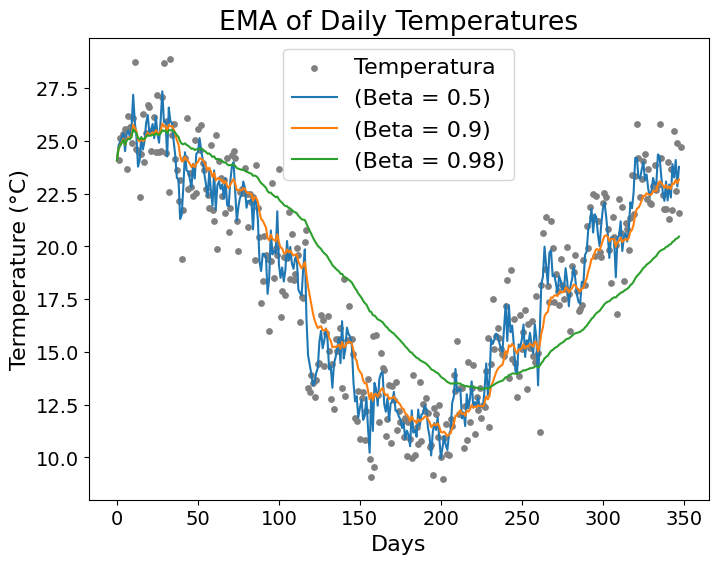

In [ ]:
def ema_with_bias_correction(data_points, beta=0.9, correction_limit=1, episolon=1e-08):
  emas = []
  vt = 0  # Initialize the moving average
  for t in range(0, len(data_points)):
      vt = beta * vt + (1 - beta) * data_points[t]
      bias_correction = 1.0 - beta**(t+1)
      emas.append(vt/bias_correction)
  return emas

# Calculate EMA curves for each beta value
ema_curves = {}
for beta in beta_values:
    ema_curves[beta] = ema_with_bias_correction(daily_temperatures_southern, beta)

# Create a scatterplot
plt.figure(figsize=(8, 6))

# Plot temperature data as a scatter plot
days = range(1, len(daily_temperatures_southern) + 1)
plt.scatter(days, daily_temperatures_southern, label='Temperatura', color='grey', s=15, marker='o')

# Plot EMA curves for each beta value
for beta, curve in ema_curves.items():
    plt.plot(curve, label=f'(Beta = {beta})')

plt.title('EMA of Daily Temperatures')
plt.xlabel('Days')
plt.ylabel('Termperature (°C)')
plt.legend()
plt.show()

# Comparing Optimization Algorithms

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()


100%|██████████| 9.91M/9.91M [00:00<00:00, 56.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.66MB/s]


## Gradient Descent with Momentum

In [ ]:
model_SGD = MLP().to(device)
optimizer = optim.SGD(model_SGD.parameters(), lr=0.01, momentum=0.9)

epochs = 5
for epoch in range(epochs):
    model_SGD.train()
    total_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model_SGD(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(train_loader):.4f}")

model_SGD.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model_SGD(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()

print(f"Test Accuracy: {correct / len(test_loader.dataset) * 100:.2f}%")

Epoch 1/5, Loss: 0.3212
Epoch 2/5, Loss: 0.1055
Epoch 3/5, Loss: 0.0709
Epoch 4/5, Loss: 0.0501
Epoch 5/5, Loss: 0.0369
Test Accuracy: 97.64%


## RMSProp

In [ ]:
model_RMS = MLP().to(device)
optimizer = optim.RMSprop(model_RMS.parameters(), lr=0.01, momentum=0.9) #RMSProp and Adam's with the same lr of SGD. Default (0.001) is recommended

epochs = 5
for epoch in range(epochs):
    model_RMS.train()
    total_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model_RMS(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(train_loader):.4f}")

model_RMS.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model_RMS(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()

print(f"Test Accuracy: {correct / len(test_loader.dataset) * 100:.2f}%")

Epoch 1/5, Loss: 15.5580
Epoch 2/5, Loss: 2.3108
Epoch 3/5, Loss: 2.3099
Epoch 4/5, Loss: 2.3100
Epoch 5/5, Loss: 2.3104
Test Accuracy: 9.58%


## Adam

In [ ]:
model_Adam = MLP().to(device)
optimizer = optim.Adam(model_Adam.parameters(), lr=0.01, betas=(0.9, 0.999)) #betas with default value

epochs = 5
for epoch in range(epochs):
    model_Adam.train()
    total_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model_Adam(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(train_loader):.4f}")

model_Adam.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model_Adam(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()

print(f"Test Accuracy: {correct / len(test_loader.dataset) * 100:.2f}%")

Epoch 1/5, Loss: 0.2786
Epoch 2/5, Loss: 0.1871
Epoch 3/5, Loss: 0.1611
Epoch 4/5, Loss: 0.1482
Epoch 5/5, Loss: 0.1430
Test Accuracy: 96.54%


## AdamW

In [ ]:
model_AdamW = MLP().to(device)
optimizer = optim.AdamW(model_AdamW.parameters(), lr=0.01, betas=(0.9, 0.999)) #betas with default value

epochs = 5
for epoch in range(epochs):
    model_AdamW.train()
    total_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model_AdamW(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(train_loader):.4f}")

model_AdamW.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model_AdamW(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()

print(f"Test Accuracy: {correct / len(test_loader.dataset) * 100:.2f}%")

Epoch 1/5, Loss: 0.2767
Epoch 2/5, Loss: 0.1822
Epoch 3/5, Loss: 0.1638
Epoch 4/5, Loss: 0.1595
Epoch 5/5, Loss: 0.1417
Test Accuracy: 95.27%
